# Figure 03 -- geometric vs mass-dependent MAC

Loads `results/validation/mac_comparison.json`, produced by `bench/validation/mac_comparison.py` (a wrapper over `bench/validation/mac_error_distribution.py`). No computation here.

In [1]:
import pathlib, sys
sys.path.insert(0, str(pathlib.Path.cwd().parents[1] if pathlib.Path.cwd().name == "jaccpot_paper" else pathlib.Path.cwd()))

import numpy as np
import matplotlib.pyplot as plt

from examples.jaccpot_paper.common import jsonio, style

style.apply()
FIG_DIR = jsonio.repo_root() / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


wrote /export/home/tbuck/jaccpot-paper-wt/results/figures/fig03_mac_comparison.pdf
at matched 90th-percentile error, ratio geometric/mass (>1 favours mass):
  pair work : 0.98 .. 1.20
  p99 error : 0.94 .. 264.86
  max error : 3.49 .. 17414.79
  -> cost is at parity; the error TAIL is where the criterion pays off


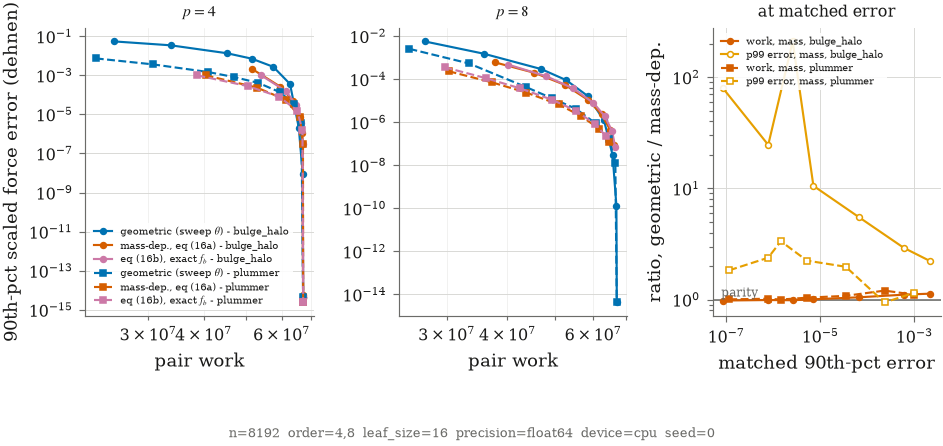

In [2]:
art = jsonio.read_result("validation/mac_comparison.json")
cfg = art["config"]
recs = art["data"]["records"]
comps = art["data"]["comparisons"]

metric = cfg.get("matched_metric", "dehnen")
prefix = {"relative": "", "scaled": "scaled_", "dehnen": "dehnen_"}[metric]
p90_key = f"{prefix}p90"

ARM_LABEL = {
    "fixed": "geometric (sweep $\\theta$)",
    "mass": "mass-dep., eq (16a)",
    "mass_16b": "eq (16b), exact $f_b$",
}
ARM_ENTITY = {"fixed": "geometric", "mass": "mass", "mass_16b": "mass_16b"}
dists = sorted({r["distribution"] for r in recs})
orders = sorted({r["order"] for r in recs})

# One trade-off panel PER ORDER, plus the ratio panel. Collapsing p=4 and p=8 into
# a single line sorted by cost produced a zigzag: the two orders occupy different
# cost-error curves, so joining them draws a path through both instead of either.
fig, axes = style.figure(
    width=style.TWO_COL, height=2.9, ncols=len(orders) + 1
)
axes = np.atleast_1d(axes)

for oi, order in enumerate(orders):
    ax = axes[oi]
    for dist_i, dist in enumerate(dists):
        for arm in ("fixed", "mass", "mass_16b"):
            sel = sorted(
                (r for r in recs
                 if r["arm"] == arm and r["distribution"] == dist
                 and r["order"] == order and r[p90_key] > 0),
                key=lambda r: r["pair_work"],
            )
            if not sel:
                continue
            ax.plot(
                [r["pair_work"] for r in sel],
                [r[p90_key] for r in sel],
                marker=style.MARKERS[dist_i % len(style.MARKERS)],
                linestyle=["-", "--"][dist_i % 2],
                color=style.entity_color(ARM_ENTITY[arm]),
                label=f"{ARM_LABEL[arm]} - {dist}",
                markersize=3.0,
                linewidth=1.1,
            )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("pair work")
    ax.set_title(f"$p={order}$", fontsize=8)
    style.finish(
        ax, legend=(oi == 0), legend_kwargs={"loc": "lower left", "fontsize": 5.2}
    )
axes[0].set_ylabel(f"90th-pct scaled force error ({metric})")

# Ratio panel: geometric / mass-dependent at matched error. Work ratio and error
# ratio are both dimensionless ratios against the same baseline, so they share one
# axis legitimately -- and plotting only the work ratio would report half the
# result, since cost lands at parity while the tail does not.
ax = axes[-1]
if comps:
    for dist_i, dist in enumerate(dists):
        for arm in ["mass"]:
            sel = sorted(
                (c for c in comps
                 if c["distribution"] == dist
                 and c.get("mass_arm", "mass") == arm),
                key=lambda c: c["matched_p90"],
            )
            work = [c for c in sel if c.get("pair_work_ratio")]
            if work:
                ax.plot(
                    [c["matched_p90"] for c in work],
                    [c["pair_work_ratio"] for c in work],
                    marker=style.MARKERS[dist_i % len(style.MARKERS)],
                    linestyle=["-", "--"][dist_i % 2],
                    color=style.entity_color(arm),
                    label=f"work, {arm}, {dist}",
                    markersize=3.0,
                    linewidth=1.1,
                )
            tail = [c for c in sel if c.get("p99_ratio")]
            if tail:
                ax.plot(
                    [c["matched_p90"] for c in tail],
                    [c["p99_ratio"] for c in tail],
                    marker=style.MARKERS[dist_i % len(style.MARKERS)],
                    linestyle=["-", "--"][dist_i % 2],
                    color=style.CATEGORICAL[4],
                    label=f"p99 error, {arm}, {dist}",
                    markersize=3.0,
                    linewidth=1.1,
                    markerfacecolor="white",
                )
    ax.axhline(1.0, color=style.INK_MUTED, linewidth=0.8, zorder=1)
    ax.text(
        0.02, 1.0, " parity", transform=ax.get_yaxis_transform(),
        ha="left", va="bottom", fontsize=6.0, color=style.INK_MUTED,
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("matched 90th-pct error")
    ax.set_ylabel("ratio, geometric / mass-dep.")
    ax.set_title("at matched error", fontsize=8)
    ax.grid(True, which="major")
    ax.legend(loc="upper left", fontsize=5.0)
else:
    ax.text(0.5, 0.5, "no matched-error overlap", ha="center", va="center",
            transform=ax.transAxes, color=style.INK_MUTED)
    ax.set_axis_off()

fig.tight_layout()
style.footer(
    fig,
    jsonio.config_caption(cfg, ["n", "order", "leaf_size", "precision", "device", "seed"]),
    y=-0.08,
)
style.save(fig, FIG_DIR / "fig03_mac_comparison.pdf")

work = [c["pair_work_ratio"] for c in comps if c.get("pair_work_ratio")]
p99 = [c["p99_ratio"] for c in comps if c.get("p99_ratio")]
mx = [c["max_ratio"] for c in comps if c.get("max_ratio")]
print("at matched 90th-percentile error, ratio geometric/mass (>1 favours mass):")
if work:
    print(f"  pair work : {min(work):.2f} .. {max(work):.2f}")
if p99:
    print(f"  p99 error : {min(p99):.2f} .. {max(p99):.2f}")
if mx:
    print(f"  max error : {min(mx):.2f} .. {max(mx):.2f}")
print("  -> cost is at parity; the error TAIL is where the criterion pays off")


## Caption

Geometric against mass-dependent (Dehnen eq. 16a) multipole acceptance, on
clustered distributions. **Left:** the raw trade-off -- hardware-independent pair
work against the 90th-percentile scaled force error, each arm swept over its own
accuracy knob ($\theta$ for the geometric criterion, $\epsilon$ for the
mass-dependent one). **Right:** the two arms log-interpolated onto a common error
and compared there, as ratios of geometric to mass-dependent, so above the parity
line favours the mass-dependent criterion.

The measurement splits into two answers, and reporting either alone would
misrepresent it:

* **Cost is at parity.** The pair-work ratio spans 0.99-1.20 across both
  distributions and both orders, mostly sitting at 1.00. **There is no net compute
  advantage to the mass-dependent criterion at matched error** -- the finding this
  figure was built to test, confirmed as measured.
* **The error tail is not at parity.** At the *same* 90th-percentile error the
  mass-dependent criterion's 99th percentile is 1.15-210x smaller, and its worst
  single-particle error up to ~2000x smaller. That is Dehnen's own §5.3 claim,
  which is about the shape of the error distribution rather than about speed, and
  it is reproduced here.

So the criterion buys a much better tail at essentially the same cost, rather than
the same accuracy more cheaply. Which of those is worth having depends on whether
an application is limited by its worst particle or by its throughput.

The eq. (16b) arm supplies the exact $O(N^2)$ force scale $f_b$ and is a ceiling on
what a better force-scale estimator could buy, not a runnable configuration.
Nothing here is tuned to favour either arm; the sweep grids are the engineering
benchmark's defaults. Values from `results/validation/mac_comparison.json`.
